# Automated annotation: CellAssign

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch
from scvi.external import CellAssign

/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.2.0


In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
#save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [90]:
l1 = sc.read('L1_annotation.h5ad')
l2 = sc.read('L2_annotation.h5ad')

celltype_markers = pd.read_csv('/home/sources/atlases/panel.tsv', sep='\t', skiprows=0)
celltype_markers = celltype_markers[~celltype_markers['Cell type'].isna()]
celltype_markers = celltype_markers[['TAIR', 'Cell type']].drop_duplicates()
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'cambium']
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'sieve element']

celltype_markers = celltype_markers.set_index('TAIR')
celltype_markers = celltype_markers.pivot(columns='Cell type', values='Cell type')
celltype_markers[~celltype_markers.isna()] = 1
celltype_markers[celltype_markers.isna()] = 0
celltype_markers['unknown'] = 0
celltype_markers = celltype_markers.astype(int)

l1.obs.index = l1.obs.index.astype("str")
l1.var.index = l1.var.index.astype("str")
l1.var_names_make_unique()
l1.obs_names_make_unique()

l2.obs.index = l2.obs.index.astype("str")
l2.var.index = l2.var.index.astype("str")
l2.var_names_make_unique()
l2.obs_names_make_unique()

l1

AnnData object with n_obs × n_vars = 4238 × 16110
    obs: 'n_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_cp', 'log1p_total_counts_cp', 'pct_counts_cp', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'cp_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'manual_celltype_annotation'
    var: 'gene_ids', 'mt', 'cp', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'manual_celltype_annotation_colors', 'n

In [91]:
celltype_markers

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
TAIR,,,,,,,,,,,,,,,,,,,
AT1G06360,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G06490,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
AT1G07370,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G07640,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
AT1G08810,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G61480,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
AT5G624701,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT5G62940,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [92]:
shared_genes_l1 = l1.var_names.intersection(celltype_markers.index)
shared_genes_l2 = l2.var_names.intersection(celltype_markers.index)

In [93]:
l1_bdata = l1[:, shared_genes_l1].copy()
l2_bdata = l2[:, shared_genes_l2].copy()

## L1 

In [101]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='counts', size_factor_key="size_factors")

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [102]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [04:54<00:00,  1.35it/s, v_num=1, train_loss_step=10.2, train_loss_epoch=10.3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:54<00:00,  1.36it/s, v_num=1, train_loss_step=10.2, train_loss_epoch=10.3]


<Axes: xlabel='epoch'>

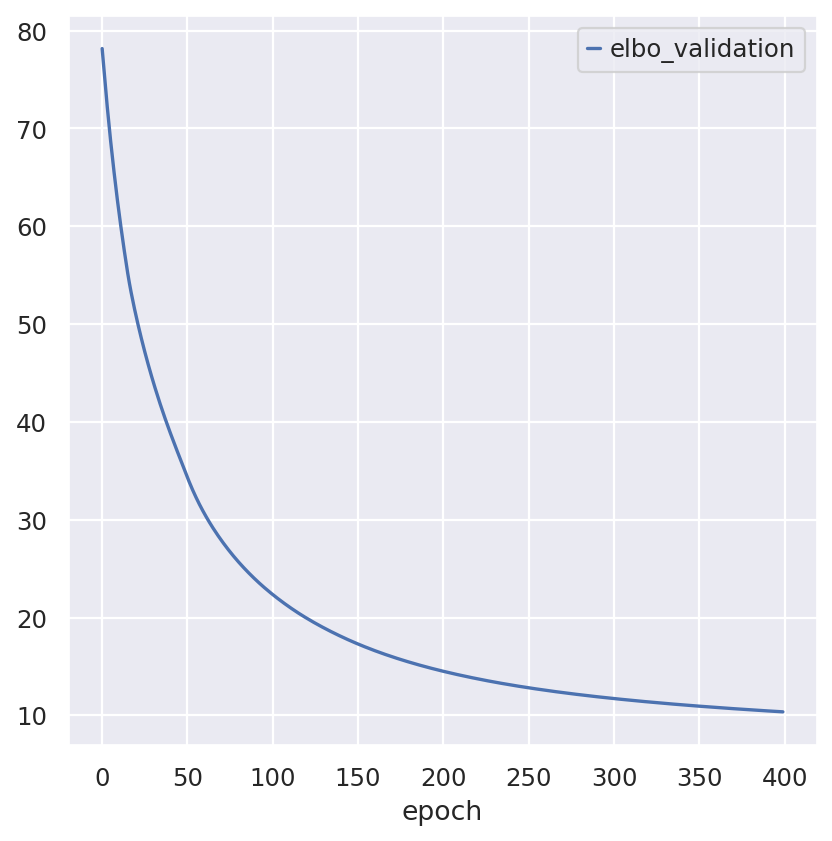

In [103]:
l1_model.history["elbo_validation"].plot()

In [104]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.001334,5.950703e-04,0.000122,0.000110,0.000007,1.244431e-06,0.008455,0.000004,9.890155e-01,0.000021,0.000047,0.000008,0.000004,0.000025,0.000085,0.000075,1.256702e-05,0.000010,0.000070
1,0.001544,1.032457e-03,0.000141,0.000127,0.000012,5.781668e-06,0.009547,0.000009,9.871395e-01,0.000028,0.000066,0.000014,0.000008,0.000037,0.000108,0.000087,4.466901e-23,0.000015,0.000081
2,0.001329,5.871951e-04,0.000121,0.000110,0.000007,1.215769e-06,0.008425,0.000004,9.890728e-01,0.000021,0.000047,0.000008,0.000004,0.000025,0.000084,0.000075,3.755421e-24,0.000009,0.000069
3,0.128605,7.461377e-11,0.011749,0.010610,0.000649,6.320013e-14,0.814881,0.000378,6.554701e-08,0.002022,0.004488,0.000769,0.000374,0.002450,0.008163,0.007236,1.865205e-22,0.000920,0.006707
4,0.001943,1.835399e-03,0.000177,0.000160,0.000024,9.123207e-06,0.011829,0.000019,9.833266e-01,0.000049,0.000117,0.000028,0.000017,0.000066,0.000162,0.000109,9.021102e-15,0.000027,0.000101


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


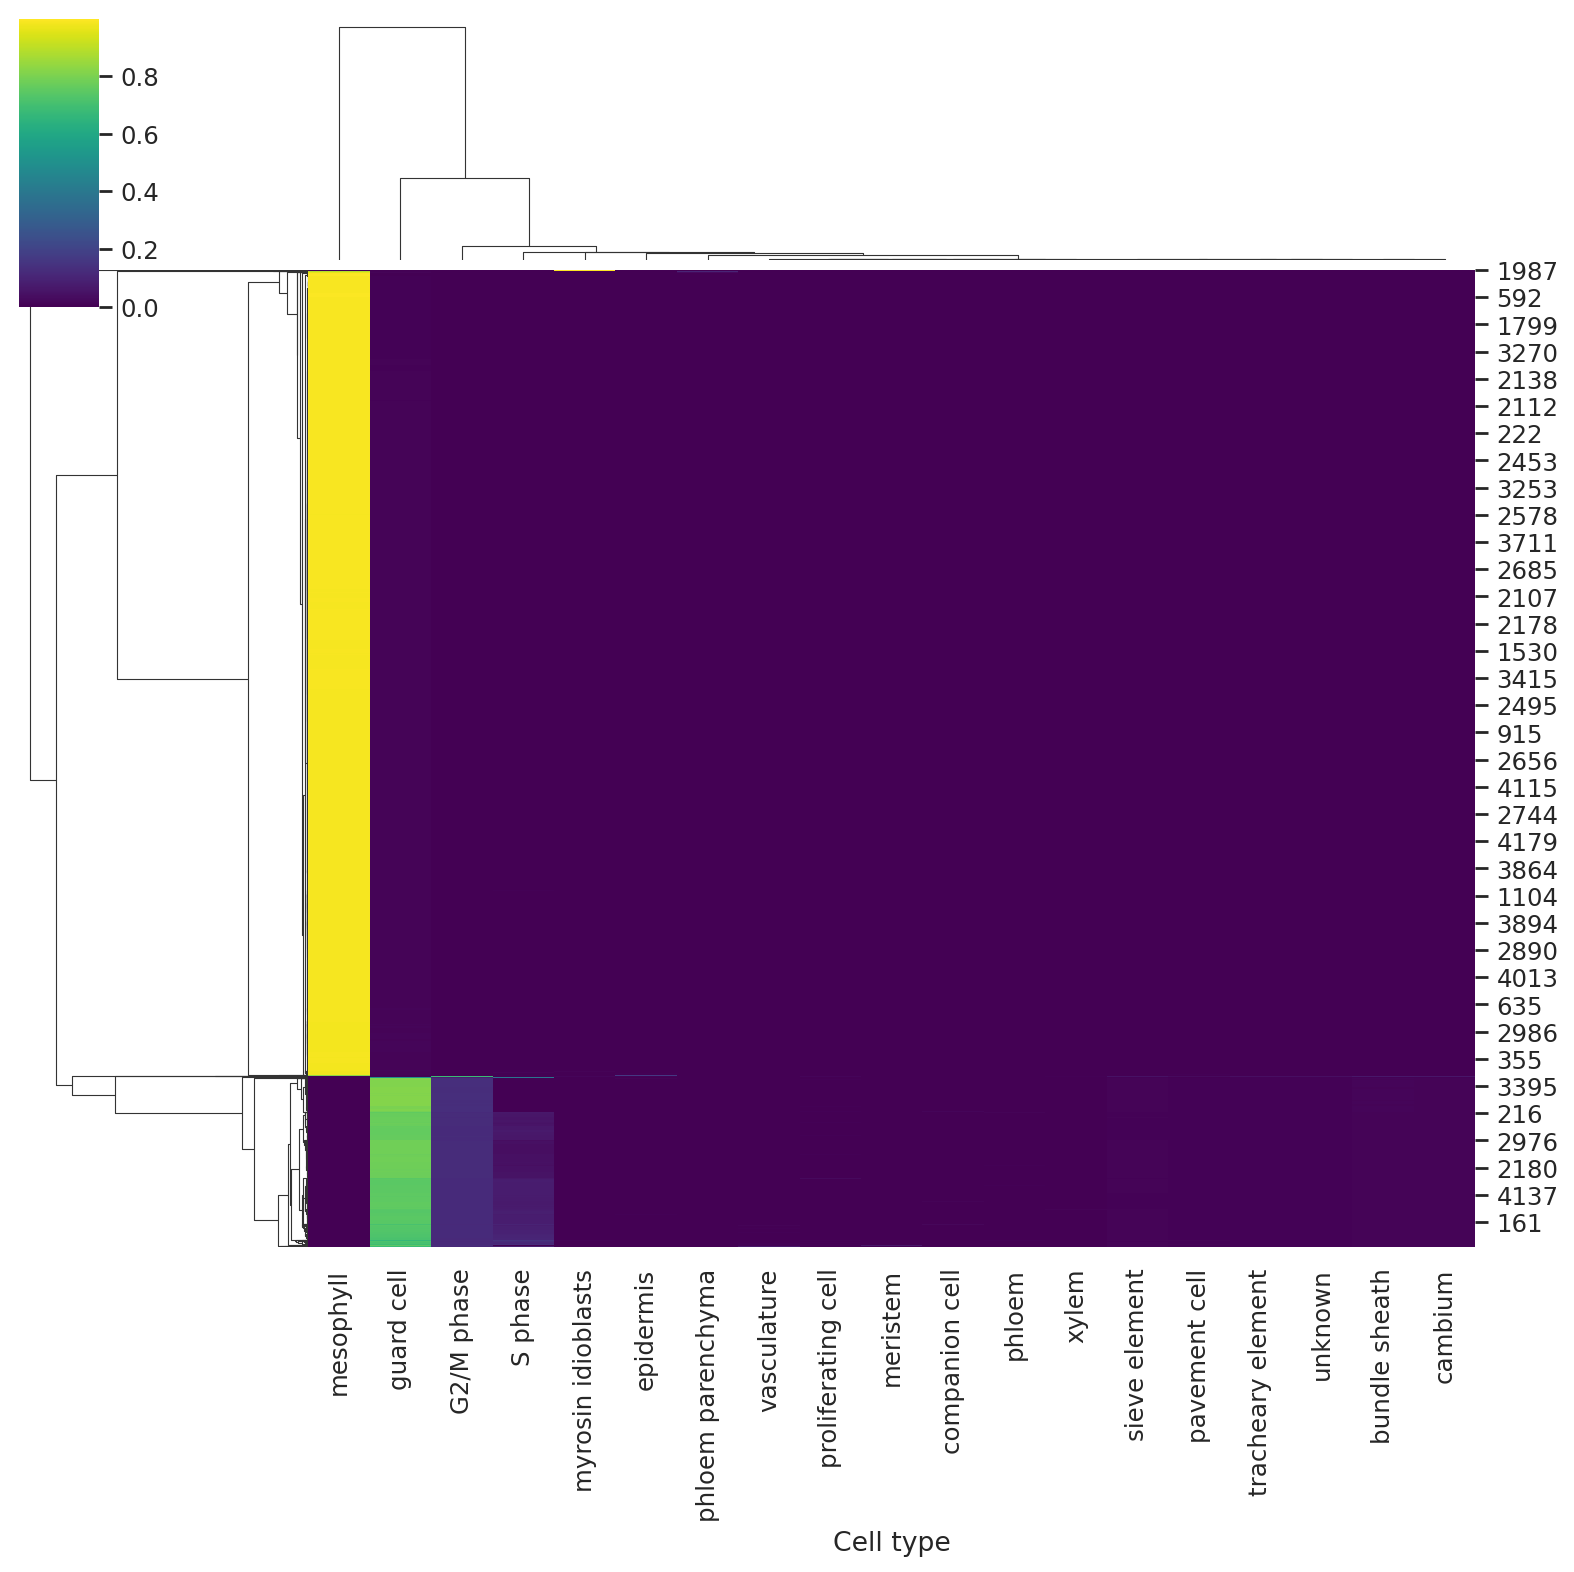

In [105]:
sns.clustermap(predictions, cmap="viridis")

In [106]:
l1_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

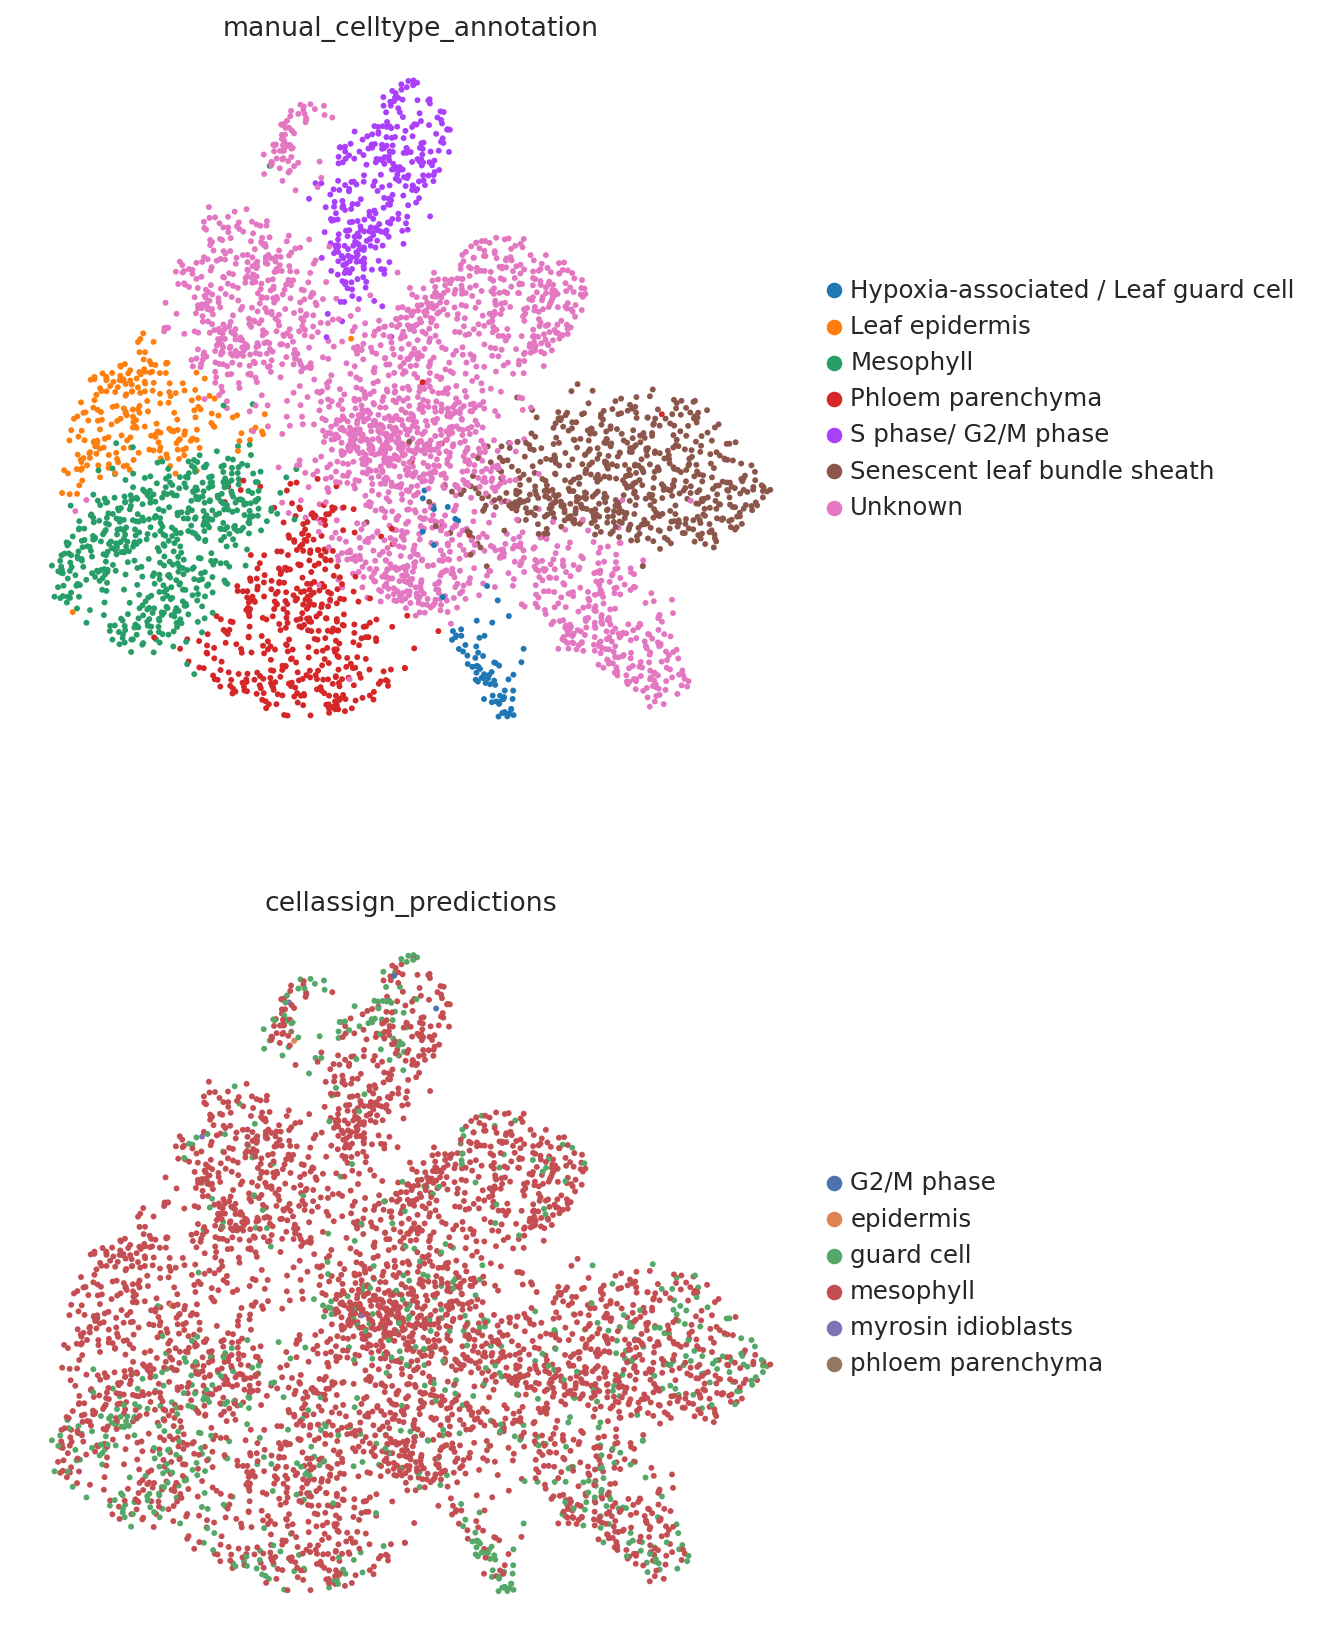

In [107]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L2

In [108]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='counts', size_factor_key="size_factors")

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [109]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [02:50<00:00,  2.37it/s, v_num=1, train_loss_step=12.4, train_loss_epoch=12]  

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [02:50<00:00,  2.34it/s, v_num=1, train_loss_step=12.4, train_loss_epoch=12]


<Axes: xlabel='epoch'>

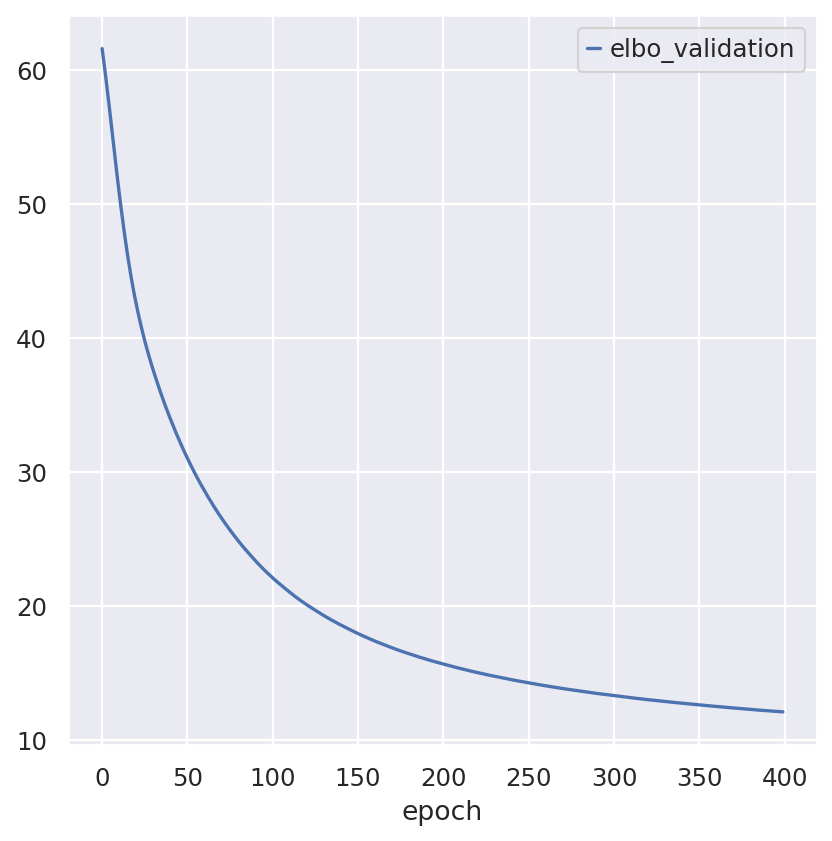

In [110]:
l2_model.history["elbo_validation"].plot()

In [111]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.000009,3.876281e-05,0.000020,0.000004,2.412549e-07,0.995922,1.947398e-06,3.689305e-07,6.739833e-07,0.000003,1.823874e-06,8.525358e-07,0.000002,1.473147e-06,0.003914,0.000019,1.697670e-07,8.892070e-07,0.000059
1,0.000026,1.117946e-04,0.000057,0.000010,5.628284e-07,0.988479,4.280343e-06,7.893144e-07,1.252666e-06,0.000008,4.080066e-06,1.775854e-06,0.000008,3.136355e-06,0.011066,0.000050,7.436016e-19,1.713138e-06,0.000165
2,0.000004,1.752964e-05,0.000009,0.000002,9.357024e-08,0.998179,7.392060e-07,1.385503e-07,2.334825e-07,0.000001,6.949856e-07,3.154064e-07,0.000001,5.518276e-07,0.001749,0.000008,1.233161e-10,3.137427e-07,0.000026
3,0.000062,2.604430e-04,0.000135,0.000026,1.403993e-06,0.972916,1.112931e-05,2.089069e-06,3.545591e-06,0.000019,1.045203e-05,4.762215e-06,0.000016,8.322623e-06,0.026008,0.000121,2.441402e-18,4.755546e-06,0.000389
4,0.000028,5.855626e-14,0.000061,0.000011,6.009871e-07,0.987867,4.094745e-06,7.209048e-07,1.021412e-06,0.000008,4.065335e-06,1.585492e-06,0.000013,2.850178e-06,0.011769,0.000053,3.164458e-12,1.456746e-06,0.000175


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


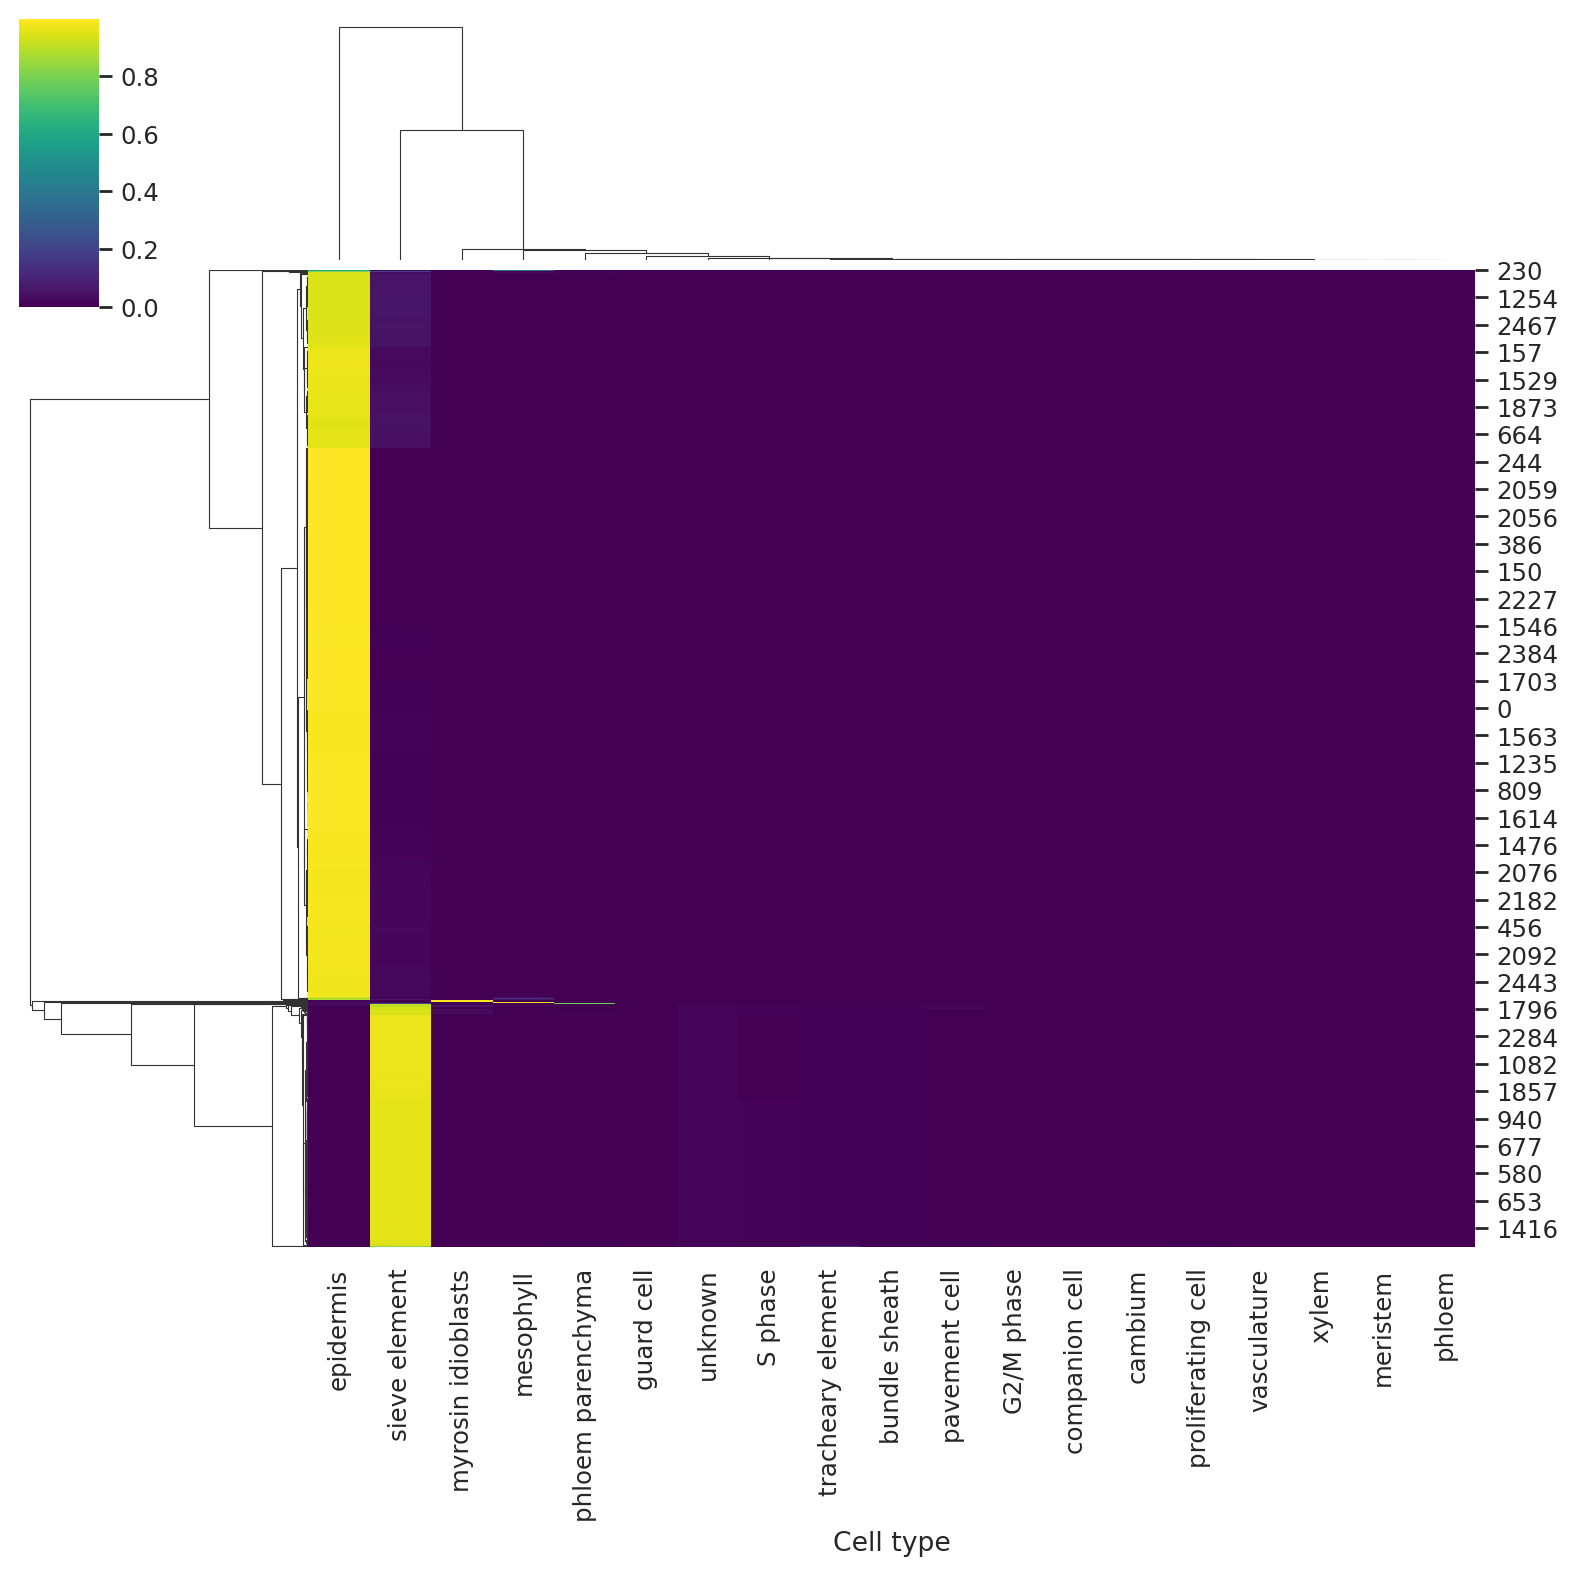

In [112]:
sns.clustermap(predictions, cmap="viridis")

In [113]:
l2_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

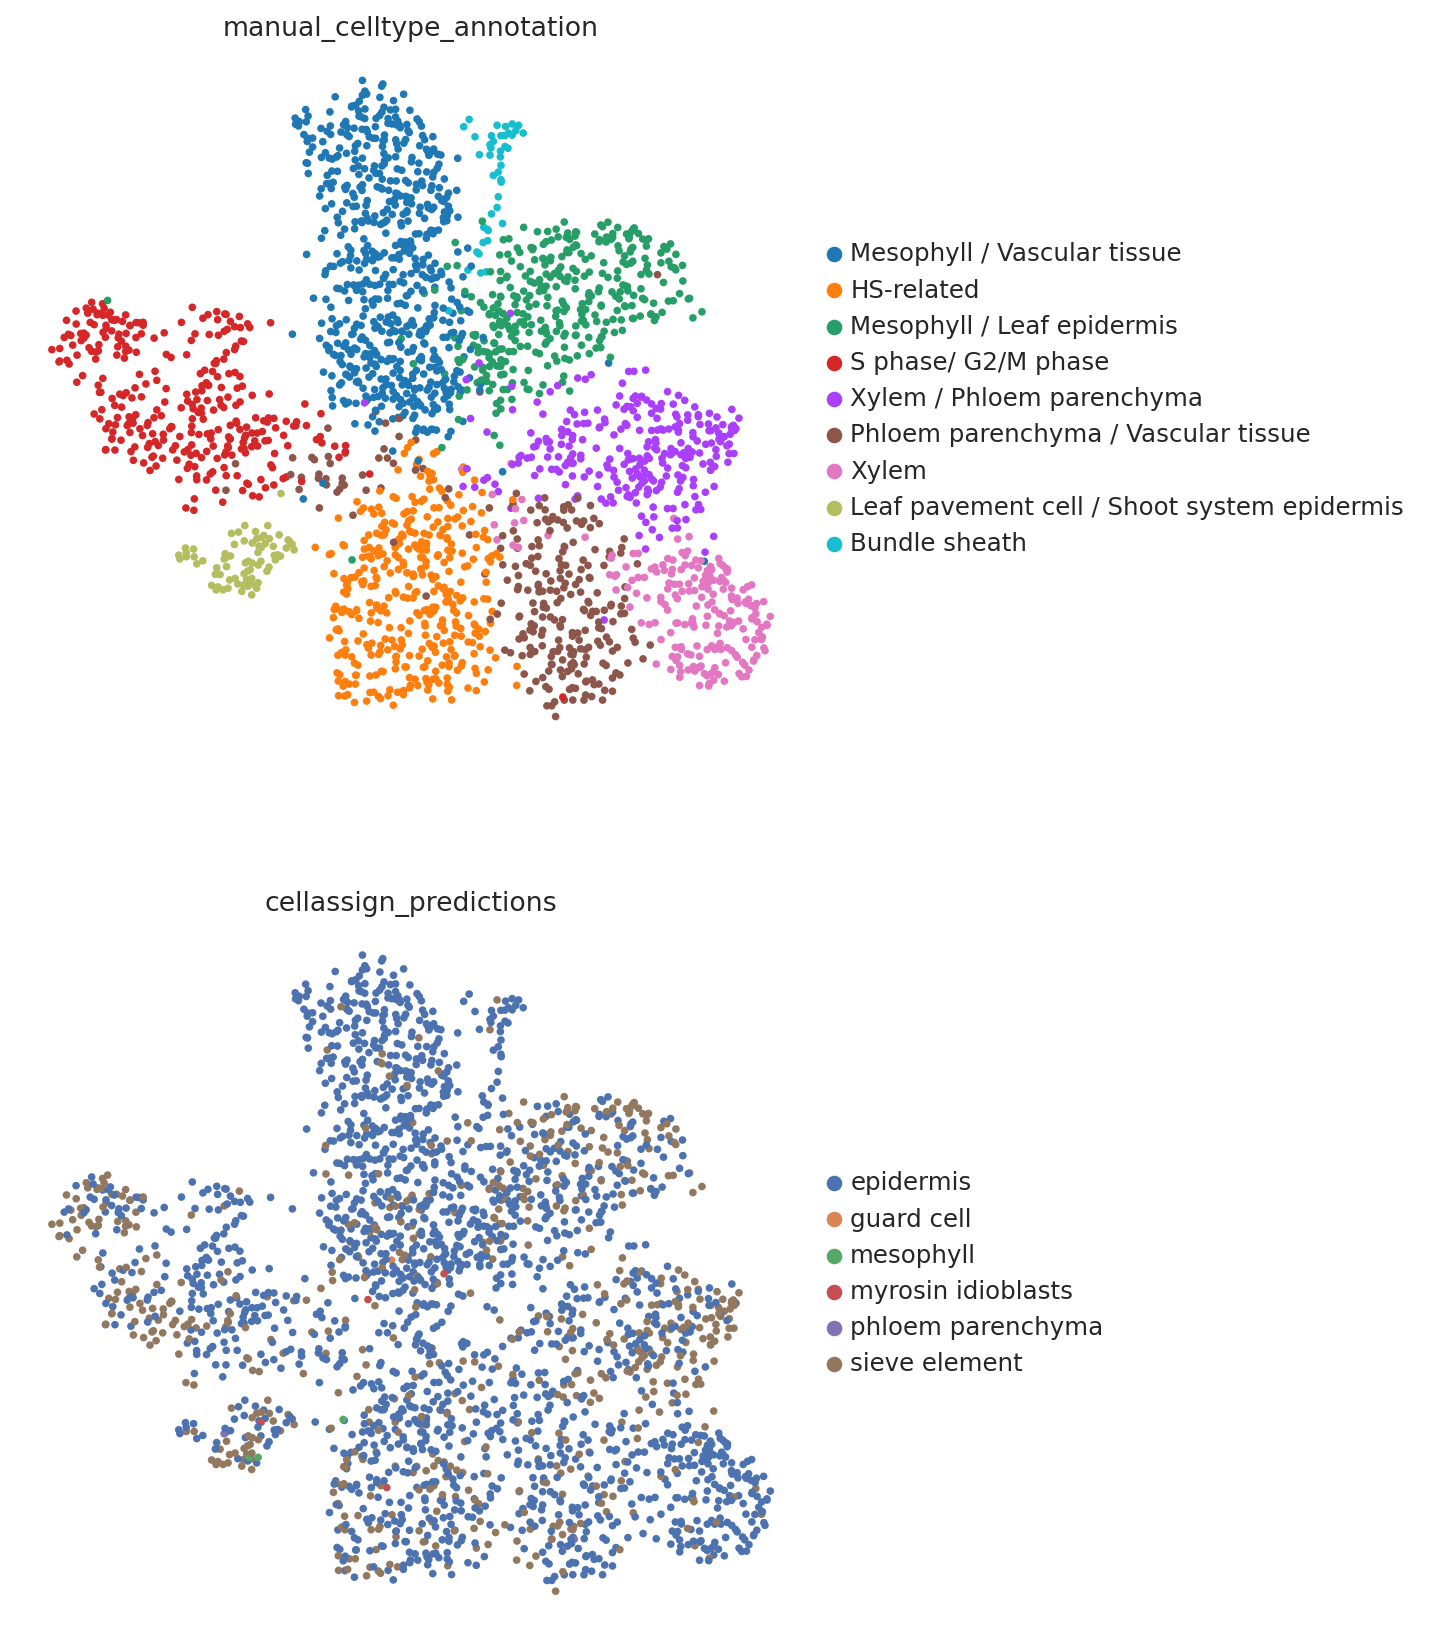

In [115]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L1 on SoupX layer

In [117]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [118]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [04:56<00:00,  1.37it/s, v_num=1, train_loss_step=12, train_loss_epoch=12]    

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:56<00:00,  1.35it/s, v_num=1, train_loss_step=12, train_loss_epoch=12]


<Axes: xlabel='epoch'>

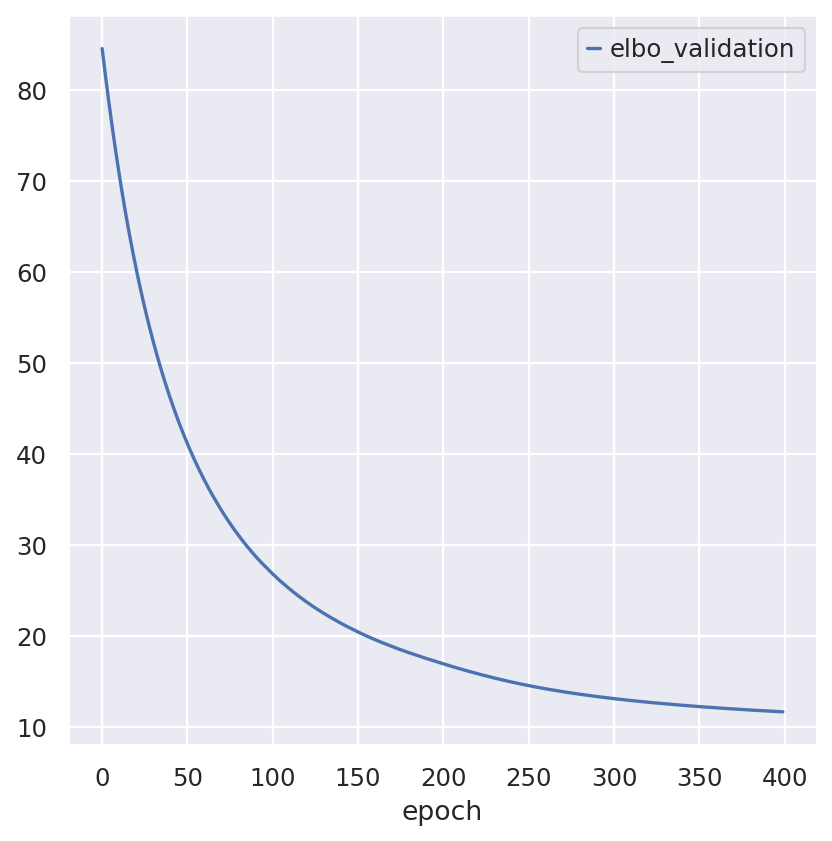

In [119]:
l1_model.history["elbo_validation"].plot()

In [120]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.981782,0.000045,0.008812,0.000252,0.000038,0.000002,0.000056,8.435045e-08,0.000011,0.000006,5.003978e-07,0.000070,0.000080,0.00001,1.231886e-07,0.008447,0.000029,4.325374e-07,0.000360
1,0.978677,0.000119,0.008784,0.000251,0.000067,0.000006,0.000100,1.476835e-06,0.000028,0.000011,7.044670e-06,0.000099,0.000116,0.00002,1.477574e-06,0.008420,0.002927,5.450708e-06,0.000359
2,0.979570,0.000044,0.008792,0.000251,0.000038,0.000002,0.000055,8.191906e-08,0.000011,0.000006,4.843040e-07,0.000069,0.000079,0.00001,1.206054e-07,0.008428,0.002284,4.190487e-07,0.000359
3,0.981383,0.000161,0.008808,0.000252,0.000038,0.000005,0.000056,8.627738e-08,0.000052,0.000006,5.132713e-07,0.000070,0.000080,0.00001,1.251498e-07,0.008444,0.000273,4.432805e-07,0.000360
4,0.981119,0.000182,0.008806,0.000252,0.000099,0.000015,0.000139,8.548668e-06,0.000046,0.000017,2.587144e-05,0.000126,0.000152,0.00003,9.944538e-06,0.008441,0.000155,1.838586e-05,0.000360


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


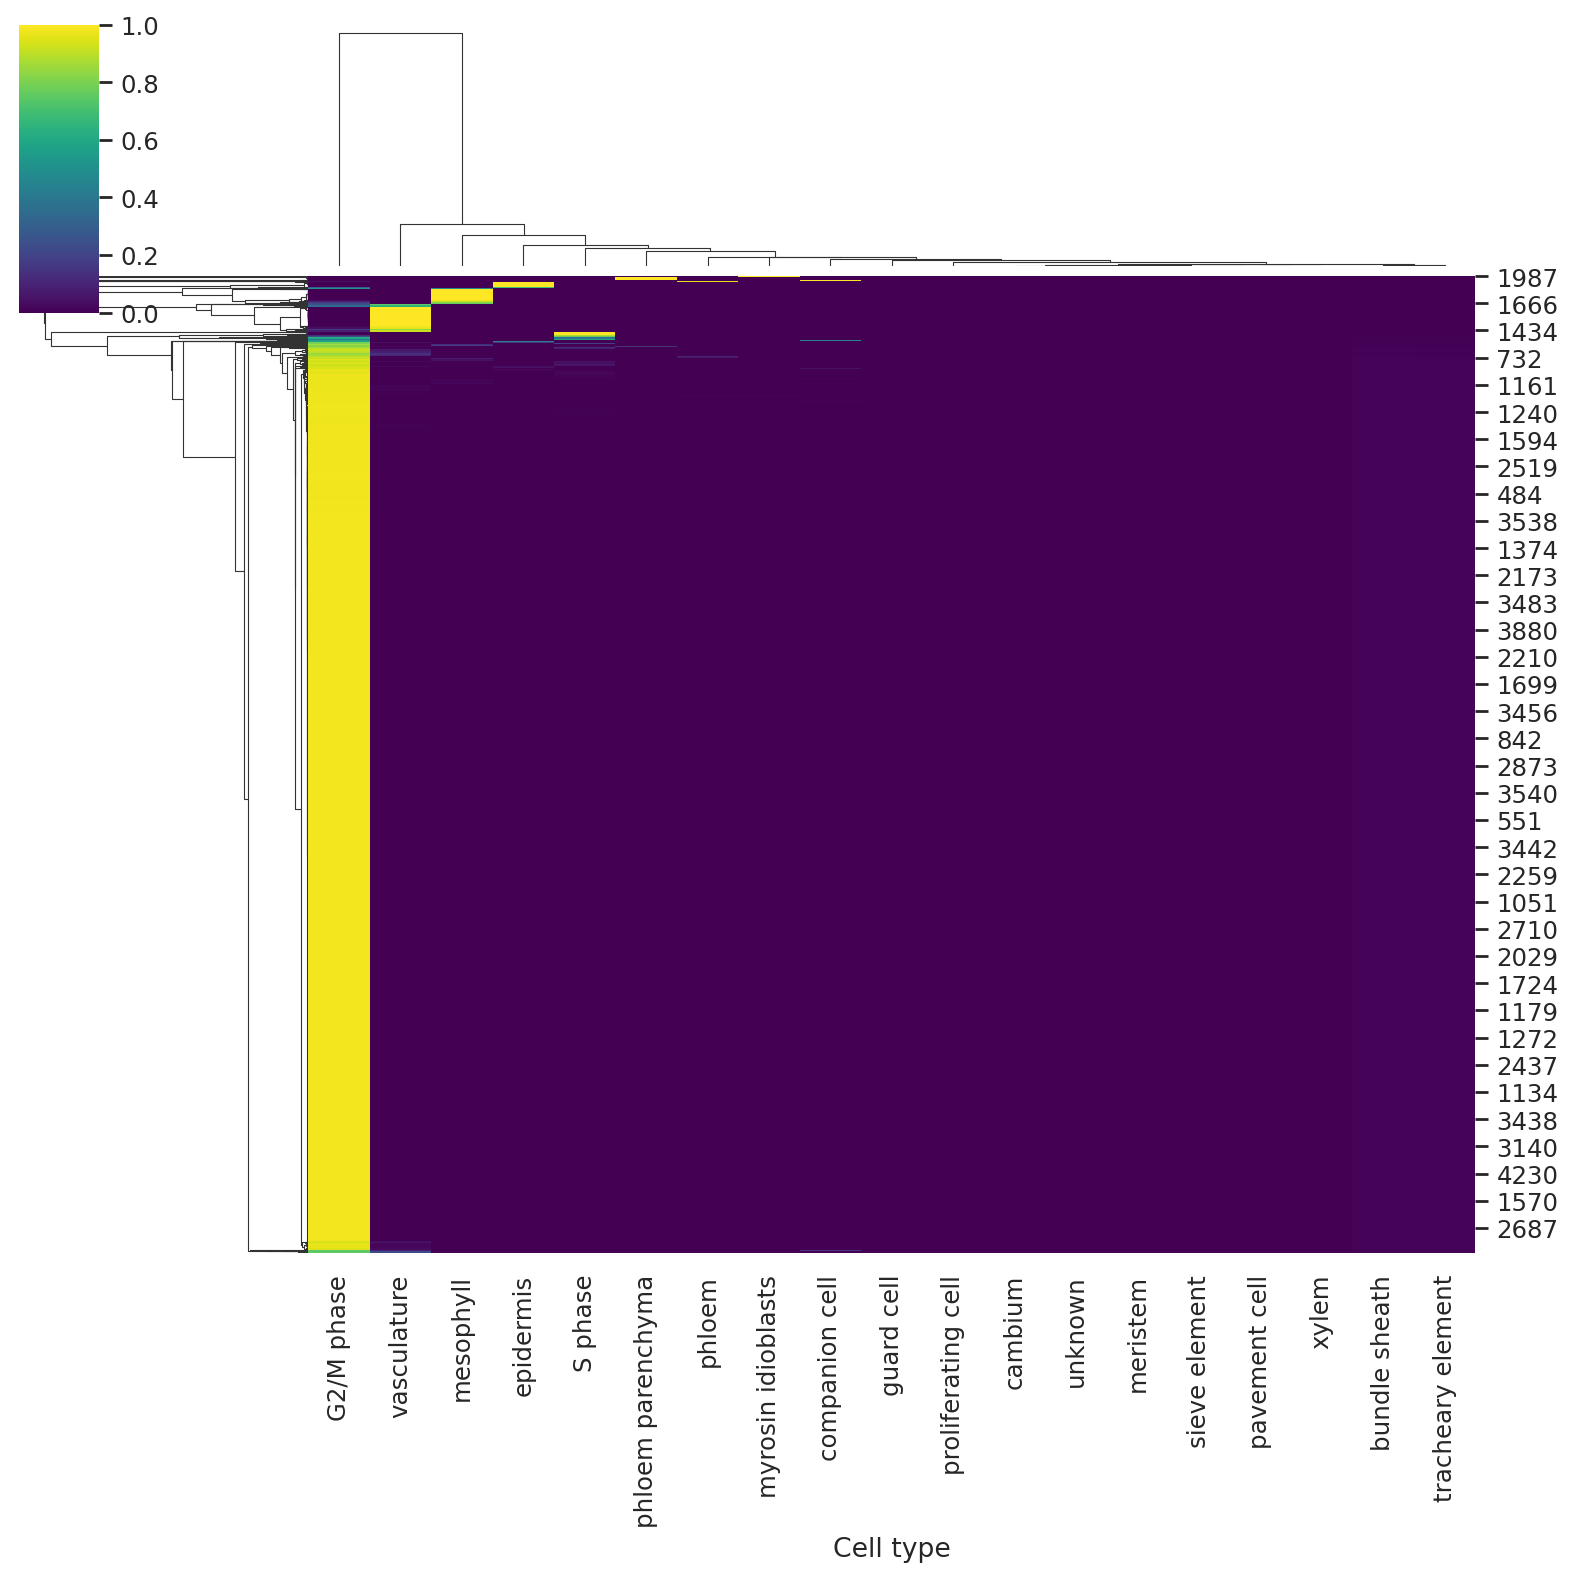

In [121]:
sns.clustermap(predictions, cmap="viridis")

In [122]:
l1_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

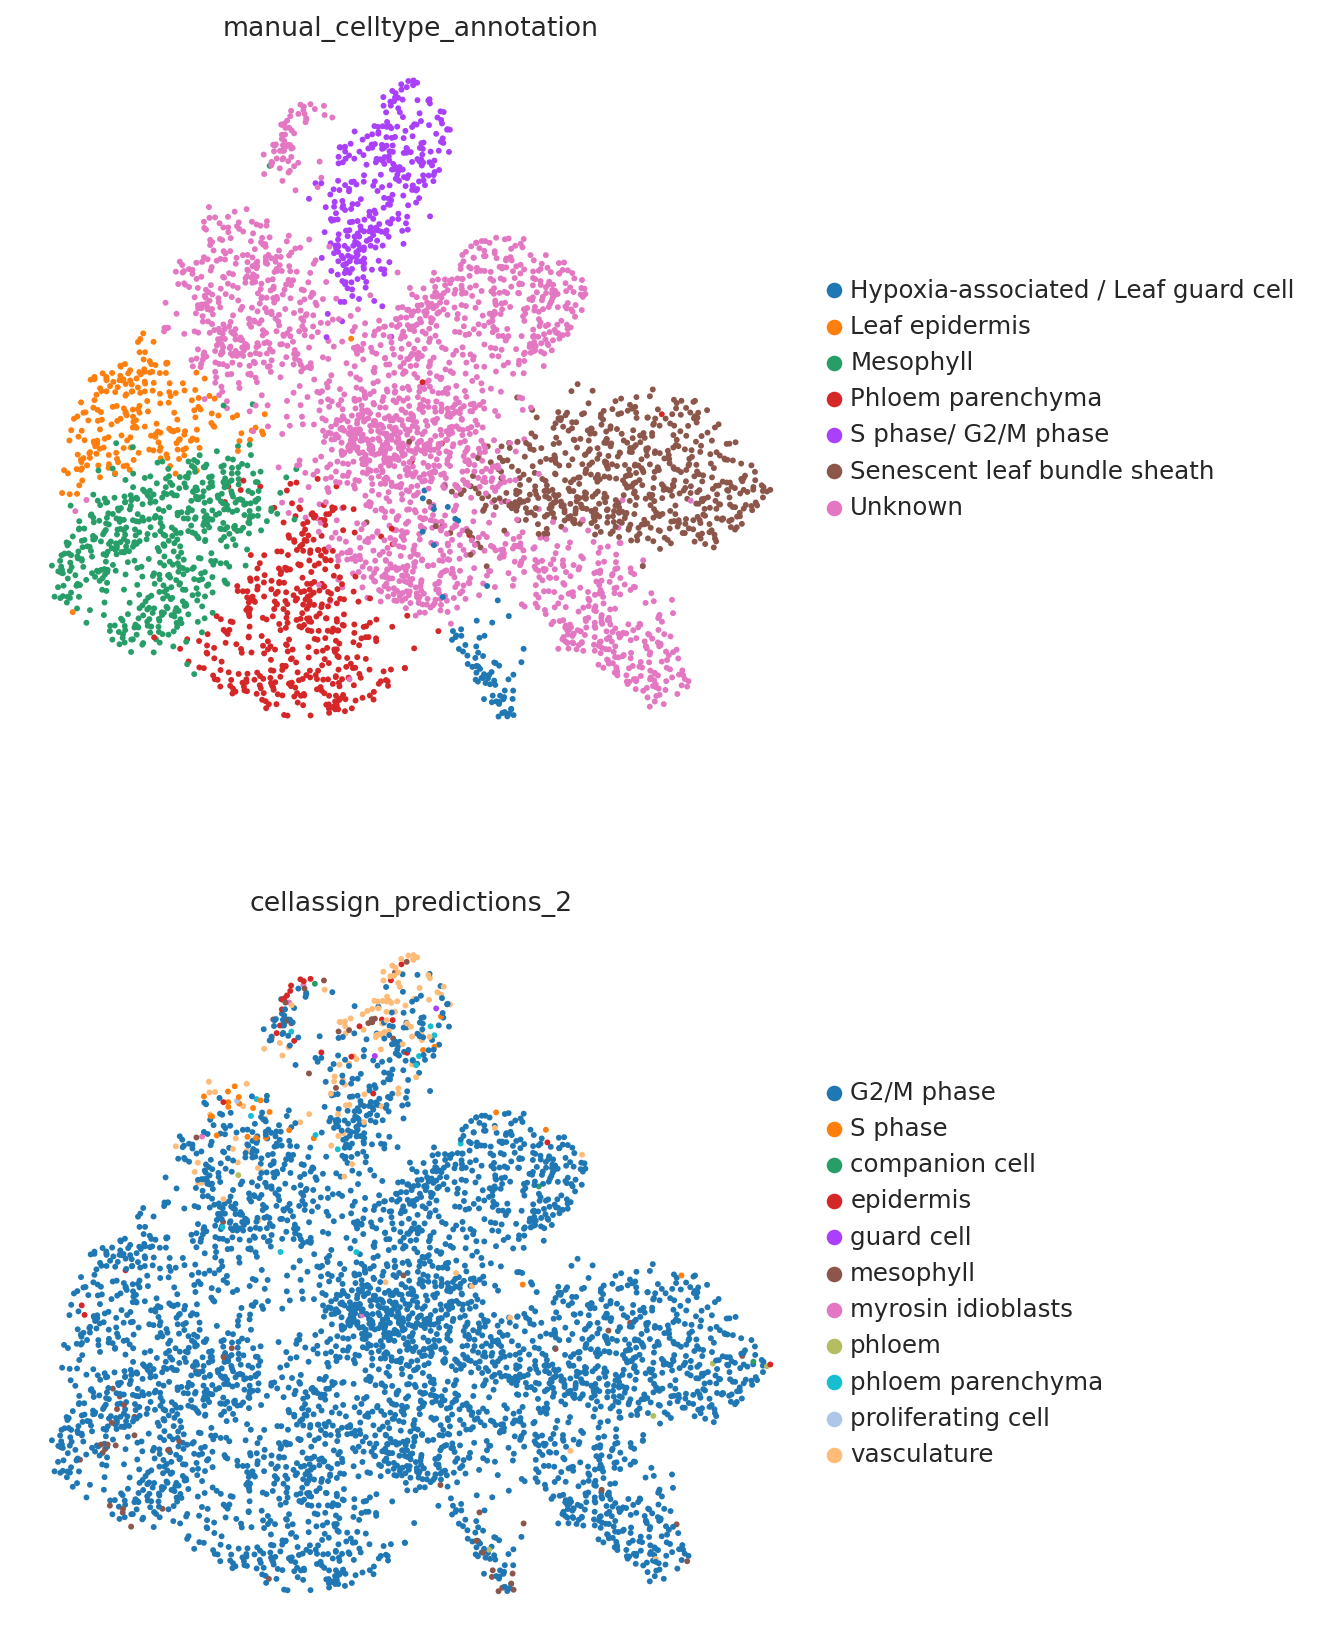

In [133]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

## L2 on SoupX layer

In [124]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [125]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [02:42<00:00,  2.26it/s, v_num=1, train_loss_step=16.5, train_loss_epoch=16.7]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [02:42<00:00,  2.45it/s, v_num=1, train_loss_step=16.5, train_loss_epoch=16.7]


<Axes: xlabel='epoch'>

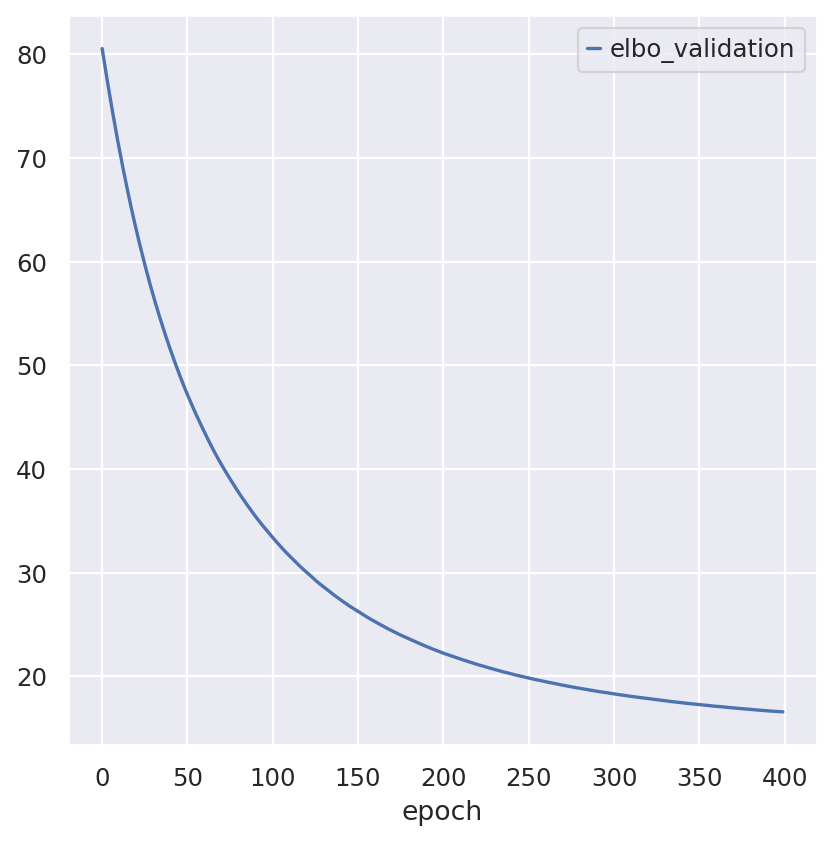

In [126]:
l2_model.history["elbo_validation"].plot()

In [127]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.002172,0.000057,0.005962,0.986377,0.000042,0.000011,0.000106,0.000111,0.000015,0.000030,0.000003,0.000048,0.000123,0.000078,0.000008,0.000045,3.197773e-07,0.000081,0.004730
1,0.002180,0.000038,0.005985,0.985642,0.000031,0.000010,0.000091,0.000098,0.000029,0.000023,0.000002,0.000039,0.000106,0.000063,0.000004,0.000031,8.091254e-04,0.000071,0.004748
2,0.002178,0.000045,0.005978,0.986243,0.000035,0.000185,0.000096,0.000103,0.000025,0.000025,0.000002,0.000042,0.000112,0.000069,0.000005,0.000036,1.619695e-06,0.000075,0.004743
3,0.002178,0.000046,0.005978,0.986415,0.000035,0.000006,0.000097,0.000103,0.000025,0.000026,0.000002,0.000043,0.000113,0.000069,0.000005,0.000037,4.702549e-06,0.000075,0.004743
4,0.002179,0.004308,0.005982,0.982247,0.000025,0.000010,0.000083,0.000091,0.000029,0.000019,0.000001,0.000034,0.000097,0.000055,0.000003,0.000023,3.382034e-06,0.000065,0.004746


Epoch 23/400:   6%|▌         | 22/400 [56:23<16:08:48, 153.78s/it, v_num=1, train_loss_step=59.4, train_loss_epoch=60]


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


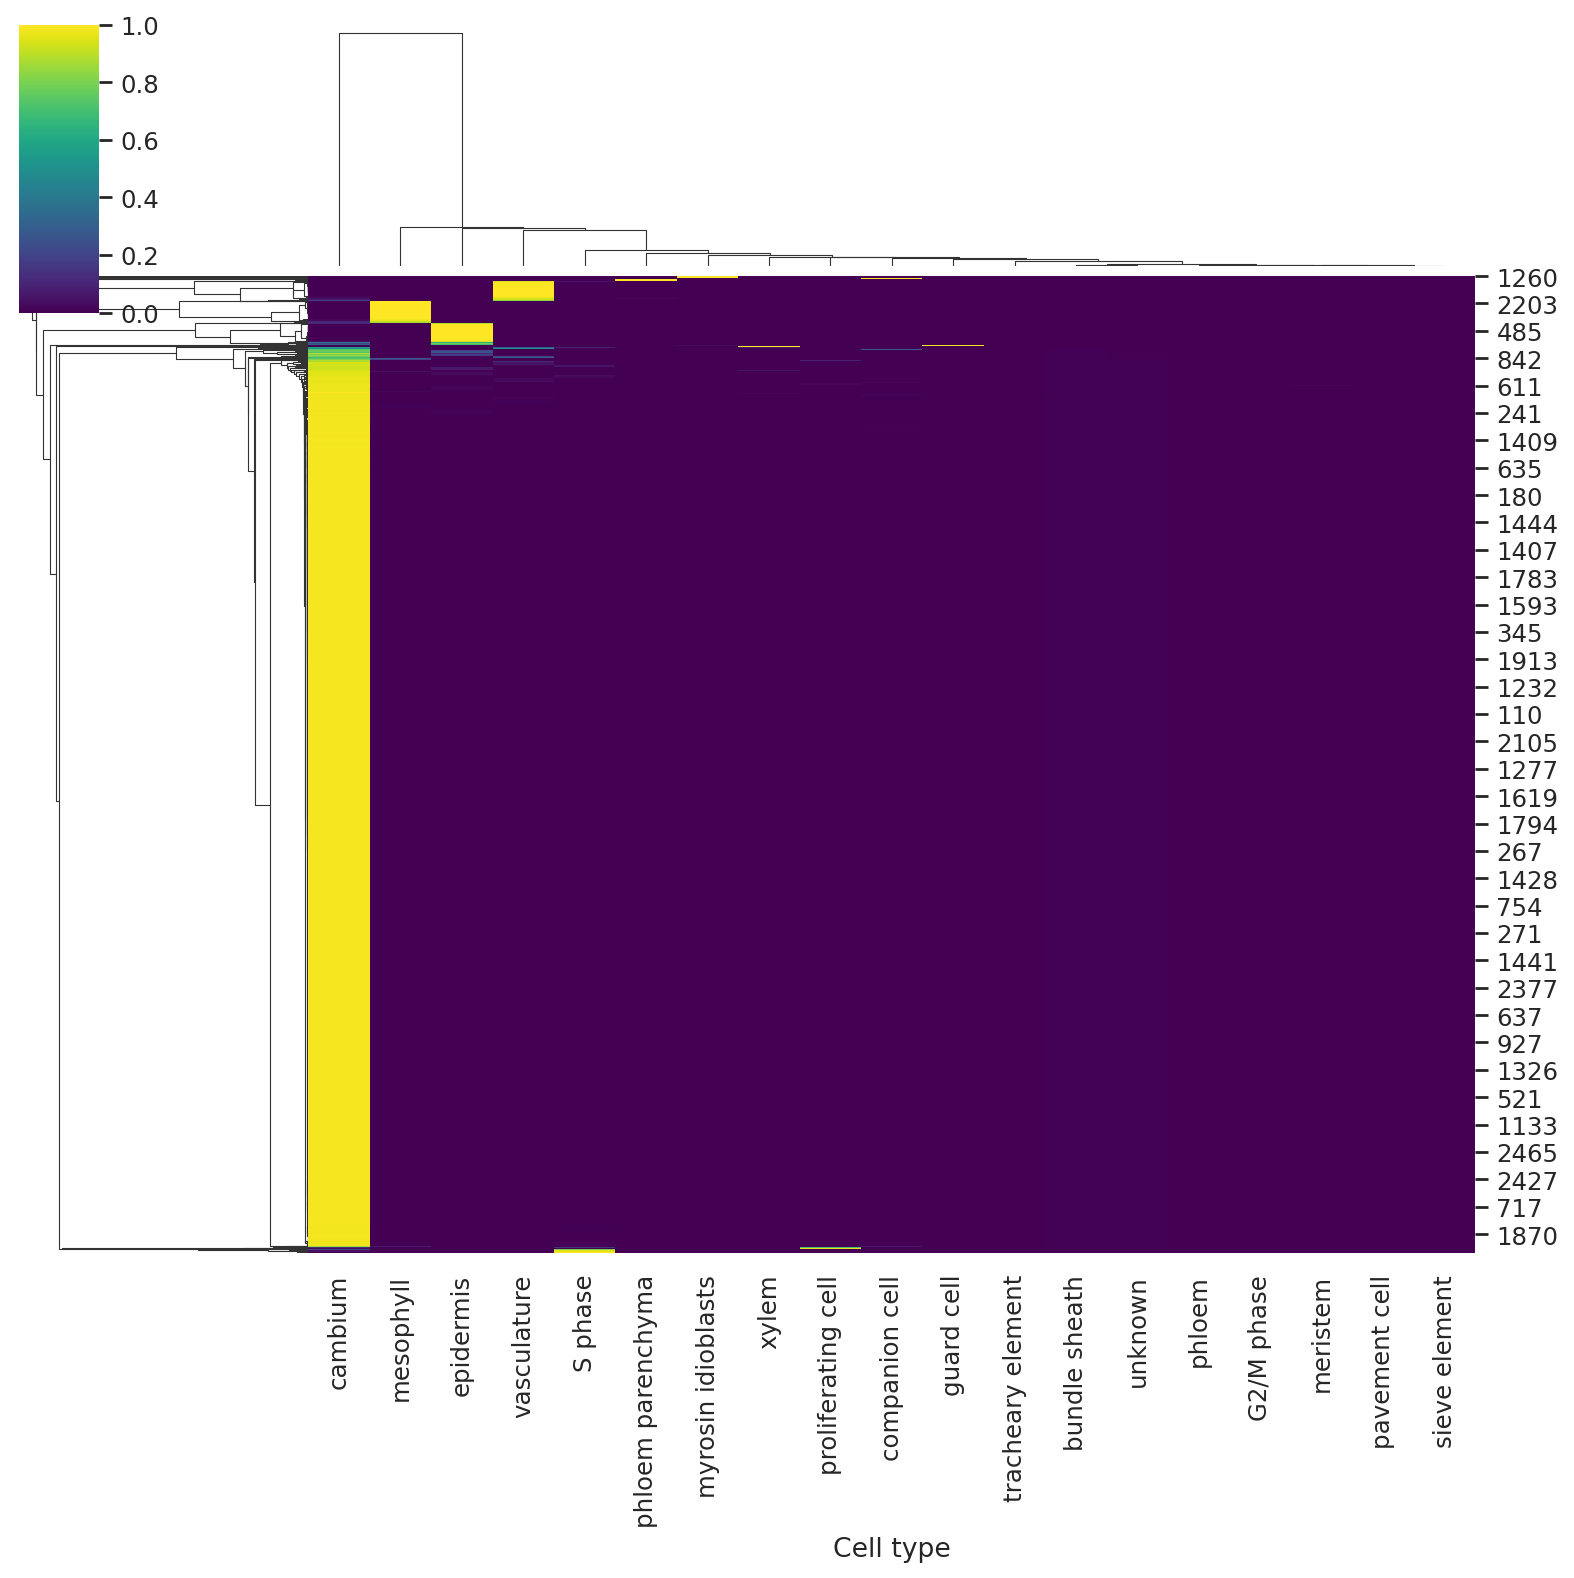

In [128]:
sns.clustermap(predictions, cmap="viridis")

In [129]:
l2_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

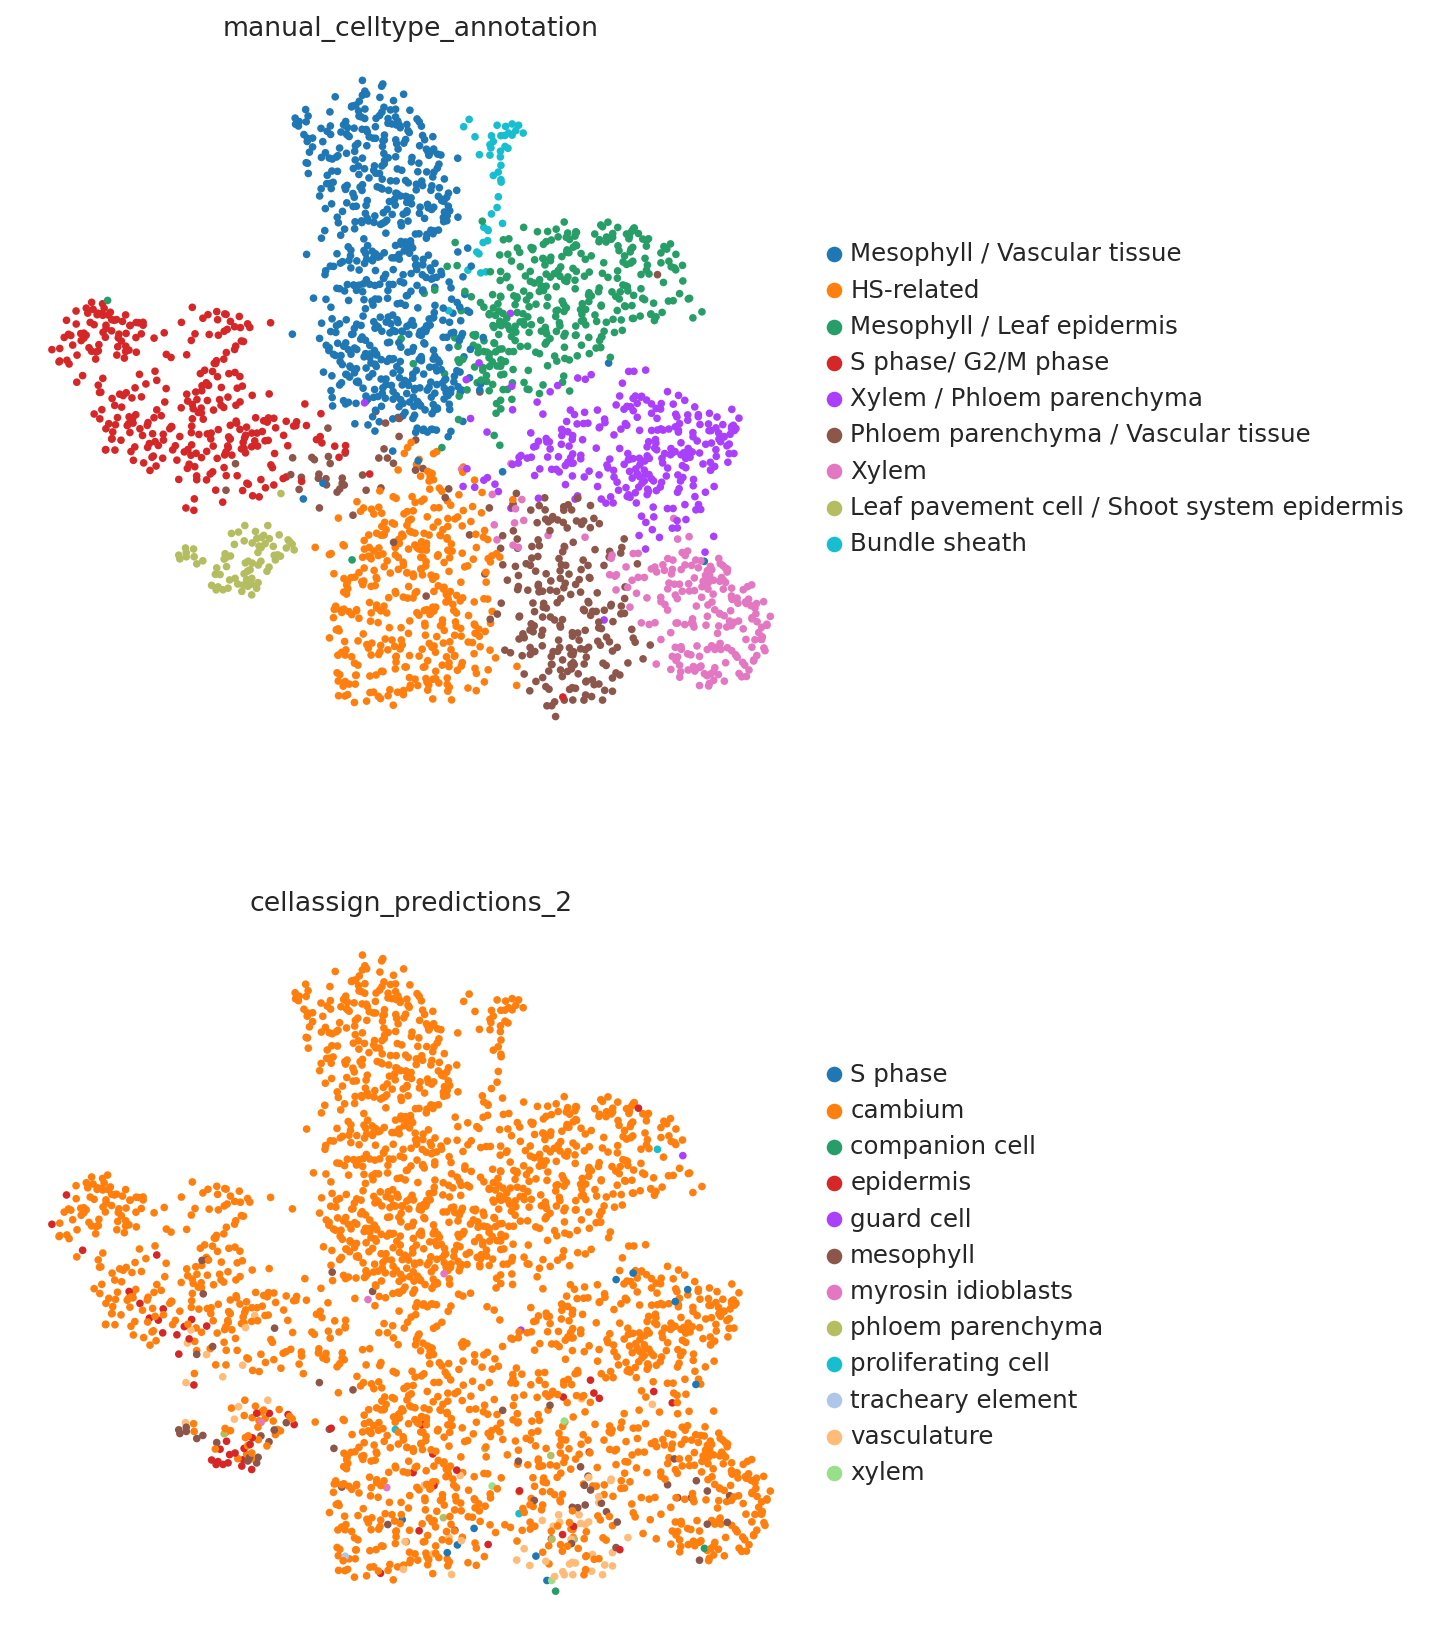

In [132]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

In [131]:
l1.write("L1_annotation.h5ad")
l2.write("L2_annotation.h5ad")